NAME: GAURI CHORGE

ROLL NO:23102B0020

CMPN-B

R-PROGRAMMING


In [1]:
install.packages("microbenchmark")
library(microbenchmark)

url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
cols <- c("age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","target")
heart <- read.csv(url, header = FALSE, col.names = cols, na.strings = "?")

set.seed(42)
idx_neg <- sample(1:nrow(heart), 5)
heart$trestbps[idx_neg] <- -heart$trestbps[idx_neg]

idx_na <- sample(1:nrow(heart), 5)
heart$trestbps[idx_na] <- NA

idx_high <- sample(1:nrow(heart), 5)
heart$trestbps[idx_high] <- 320

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
clean_bp <- function(bp) {
  if (is.na(bp)) {
    return(NA)
  } else if (bp < 0) {
    return(NA)
  } else if (bp > 250) {
    return(250)
  } else {
    return(bp)
  }
}

heart$trestbps_clean_loop <- heart$trestbps
for (i in 1:nrow(heart)) {
  heart$trestbps_clean_loop[i] <- clean_bp(heart$trestbps[i])
}

In [3]:
safe_mean_bp <- function(x) {
  tryCatch({
    m <- mean(x, na.rm = TRUE)
    if (is.nan(m)) stop("All values are NA")
    return(m)
  }, error = function(e) {
    message("Error calculating mean: ", e$message)
    return(NA)
  }, warning = function(w) {
    message("Warning: ", w$message)
    return(NA)
  })
}

safe_ratio <- function(numerator, denominator) {
  tryCatch({
    if (is.na(denominator) || is.na(numerator)) stop("Missing value in ratio calculation")
    if (denominator == 0) stop("Denominator is zero")
    return(numerator / denominator)
  }, error = function(e) {
    message("Ratio error: ", e$message)
    return(NA)
  })
}

heart$chol_bp_ratio <- mapply(safe_ratio, heart$chol, heart$trestbps_clean_loop)
mean_bp_value <- safe_mean_bp(heart$trestbps_clean_loop)

Ratio error: Missing value in ratio calculation

Ratio error: Missing value in ratio calculation

Ratio error: Missing value in ratio calculation

Ratio error: Missing value in ratio calculation

Ratio error: Missing value in ratio calculation

Ratio error: Missing value in ratio calculation

Ratio error: Missing value in ratio calculation

Ratio error: Missing value in ratio calculation



In [4]:
identify_outliers_loop <- function(x) {
  result <- logical(length(x))
  for (i in 1:length(x)) {
    if (is.na(x[i])) {
      result[i] <- FALSE
    } else if (x[i] < 0 || x[i] > 250) {
      result[i] <- TRUE
    } else {
      result[i] <- FALSE
    }
  }
  return(result)
}

identify_outliers_vectorized <- function(x) {
  ifelse(is.na(x), FALSE, x < 0 | x > 250)
}

loop_time <- system.time(identify_outliers_loop(heart$trestbps))
vector_time <- system.time(identify_outliers_vectorized(heart$trestbps))

bench_result <- microbenchmark(
  loop = identify_outliers_loop(heart$trestbps),
  vectorized = identify_outliers_vectorized(heart$trestbps),
  times = 50
)

print(loop_time)
print(vector_time)
print(bench_result)

   user  system elapsed 
  0.010   0.000   0.009 
   user  system elapsed 
      0       0       0 
Unit: microseconds
       expr    min     lq     mean  median      uq      max neval
       loop 84.063 87.915 96.17208 92.2655 101.048  135.343    50
 vectorized 18.253 19.033 89.83486 20.7930  23.181 3404.078    50


In [5]:
missing_count <- sum(is.na(heart$trestbps_clean_loop))
min_bp <- min(heart$trestbps_clean_loop, na.rm = TRUE)
max_bp <- max(heart$trestbps_clean_loop, na.rm = TRUE)
mean_bp <- mean(heart$trestbps_clean_loop, na.rm = TRUE)
median_bp <- median(heart$trestbps_clean_loop, na.rm = TRUE)
no_negative <- all(heart$trestbps_clean_loop[!is.na(heart$trestbps_clean_loop)] >= 0)
no_above_250 <- all(heart$trestbps_clean_loop[!is.na(heart$trestbps_clean_loop)] <= 250)

cat("Missing count:", missing_count, "\n")
cat("Min:", min_bp, "Max:", max_bp, "Mean:", mean_bp, "Median:", median_bp, "\n")
cat("No negative values:", no_negative, "\n")
cat("No values above 250:", no_above_250, "\n")

write.csv(heart, "cleaned_heart_data.csv", row.names = FALSE)

Missing count: 8 
Min: 94 Max: 250 Mean: 133.7661 Median: 130 
No negative values: TRUE 
No values above 250: TRUE 


In [6]:
install.packages(c("naniar", "skimr"))
library(naniar)
library(skimr)

url2 <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
adult_cols <- c("age","workclass","fnlwgt","education","education_num","marital_status",
                 "occupation","relationship","race","sex","capital_gain","capital_loss",
                 "hours_per_week","native_country","income")
adult <- read.csv(url2, header = FALSE, col.names = adult_cols, na.strings = "?", strip.white = TRUE)

set.seed(42)
idx1 <- sample(1:nrow(adult), 10)
adult$age[idx1] <- 999

idx2 <- sample(1:nrow(adult), 10)
adult$workclass[idx2] <- ""

idx3 <- sample(1:nrow(adult), 10)
adult$hours_per_week[idx3] <- NA

idx4 <- sample(1:nrow(adult), 5)
adult$capital_gain[idx4] <- NaN

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




In [7]:
na_check <- sapply(adult, function(x) sum(is.na(x)))
nan_check <- sum(is.nan(adult$capital_gain))

test_obj <- NULL
is_null_check <- is.null(test_obj)

blank_check <- sum(adult$workclass == "", na.rm = TRUE)
impossible_age_check <- sum(adult$age == 999, na.rm = TRUE)

miss_summary <- miss_var_summary(adult)
print(miss_summary)

# A tibble: 15 × 3
   variable       n_miss pct_miss
   <chr>           <int>    <num>
 1 occupation       1843   5.66  
 2 workclass        1836   5.64  
 3 native_country    583   1.79  
 4 hours_per_week     10   0.0307
 5 capital_gain        5   0.0154
 6 age                 0   0     
 7 fnlwgt              0   0     
 8 education           0   0     
 9 education_num       0   0     
10 marital_status      0   0     
11 relationship        0   0     
12 race                0   0     
13 sex                 0   0     
14 capital_loss        0   0     
15 income              0   0     


In [8]:
adult$age[adult$age == 999] <- NA
adult$workclass[adult$workclass == ""] <- "Unknown"

adult <- adult[!is.nan(adult$capital_gain), ]

complete_obs <- sum(complete.cases(adult))
incomplete_obs <- sum(!complete.cases(adult))

In [10]:
custom_median_impute <- function(x) {
  missing_idx <- is.na(x)
  med_val <- median(x, na.rm = TRUE)
  x[missing_idx] <- med_val
  return(x)
}

adult$age <- custom_median_impute(adult$age)
adult$hours_per_week <- custom_median_impute(adult$hours_per_week)

           age      workclass         fnlwgt      education  education_num 
             0           1836              0              0              0 
marital_status     occupation   relationship           race            sex 
             0           1843              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             5              0             10            583              0 
           age      workclass         fnlwgt      education  education_num 
             0           1836              0              0              0 
marital_status     occupation   relationship           race            sex 
             0           1843              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              0            583              0 
           age      workclass         fnlwgt      education  education_num 
    0.000000

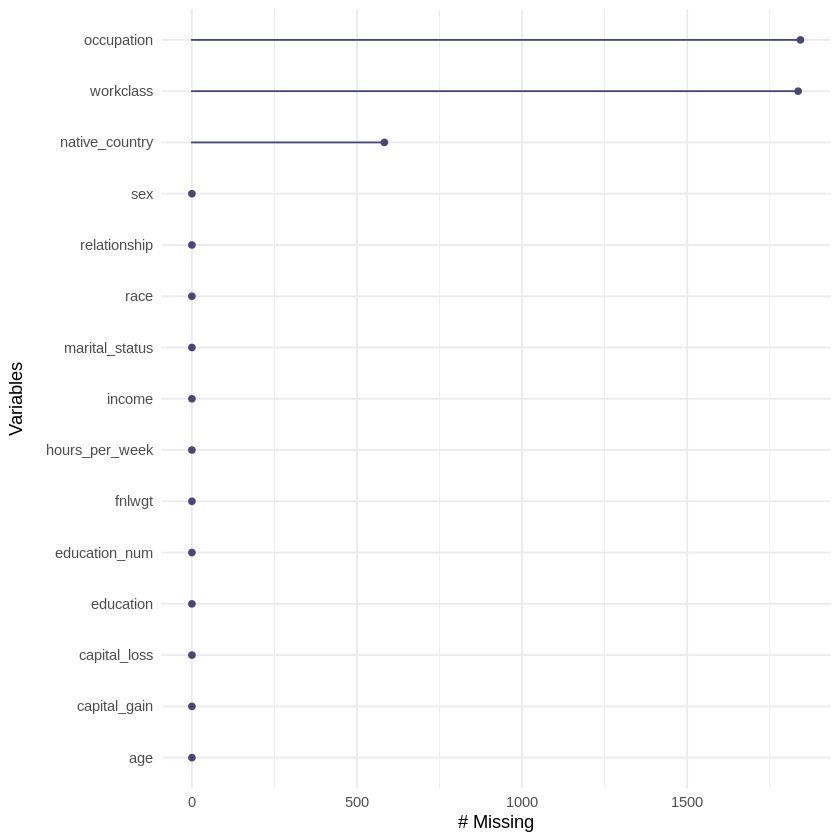

In [11]:
missing_before <- na_check
missing_after <- sapply(adult, function(x) sum(is.na(x)))

pct_missing_before <- (missing_before / nrow(adult)) * 100
pct_missing_after <- (missing_after / nrow(adult)) * 100

print(missing_before)
print(missing_after)
print(pct_missing_before)
print(pct_missing_after)

gg_miss_var(adult)

In [12]:
skim_output <- skim(adult)
print(skim_output)

verify_age <- sum(adult$age == 999, na.rm = TRUE) == 0
verify_no_na_numeric <- sum(is.na(adult$age)) == 0 && sum(is.na(adult$hours_per_week)) == 0
verify_blank_replaced <- sum(adult$workclass == "", na.rm = TRUE) == 0

cat("Complete cases:", complete_obs, "Incomplete cases:", incomplete_obs, "\n")
cat("Verify age fixed:", verify_age, "\n")
cat("Verify no NA in numeric cols:", verify_no_na_numeric, "\n")
cat("Verify blanks replaced:", verify_blank_replaced, "\n")

write.csv(adult, "cleaned_adult_data.csv", row.names = FALSE)

── Data Summary ────────────────────────
                           Values
Name                       adult 
Number of rows             32556 
Number of columns          15    
_______________________          
Column type frequency:           
  character                9     
  numeric                  6     
________________________         
Group variables            None  

── Variable type: character ────────────────────────────────────────────────────
  skim_variable  n_missing complete_rate min max empty n_unique whitespace
1 workclass           1836         0.944   7  16     0        9          0
2 education              0         1       3  12     0       16          0
3 marital_status         0         1       7  21     0        7          0
4 occupation          1843         0.943   5  17     0       14          0
5 relationship           0         1       4  14     0        6          0
6 race                   0         1       5  18     0        5          0
7 sex       